
RUNNING PIPELINE: PERMUTATION = False
Starting 5-Fold CV (Train & Test Downsampled)...

[Fold 1] Balanced Strata Counts:
  Train: {'0': 871, '1': 871}
  Test : {'1': 542, '0': 542}
  Accuracy: 0.6836

[Fold 2] Balanced Strata Counts:
  Train: {'1': 1413, '0': 1413}
  Test : {'1': 5000}
  Accuracy: 0.7048

[Fold 3] Balanced Strata Counts:
  Train: {'0': 912, '1': 912}
  Test : {'1': 501, '0': 501}
  Accuracy: 0.6198

[Fold 4] Balanced Strata Counts:
  Train: {'1': 1413, '0': 1413}
  Test : {'1': 2500}
  Accuracy: 0.7780

[Fold 5] Balanced Strata Counts:
  Train: {'0': 1043, '1': 1043}
  Test : {'0': 370, '1': 370}
  Accuracy: 0.4959

Final Mean Accuracy: 0.6564 (+/- 0.0948)

RUNNING PIPELINE: PERMUTATION = True
Starting 5-Fold CV (Train & Test Downsampled)...

[Fold 1] Balanced Strata Counts:
  Train: {'0': 871, '1': 871}
  Test : {'1': 542, '0': 542}
  Accuracy: 0.5360

[Fold 2] Balanced Strata Counts:
  Train: {'1': 1413, '0': 1413}
  Test : {'1': 5000}
  Accuracy: 0.4948

[Fold 3] B

/tmp/ipykernel_2582751/2010979079.py:129: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=results_df, x='Condition', y='Accuracy', palette=['skyblue', 'lightcoral'], capsize=.1, errorbar='sd')


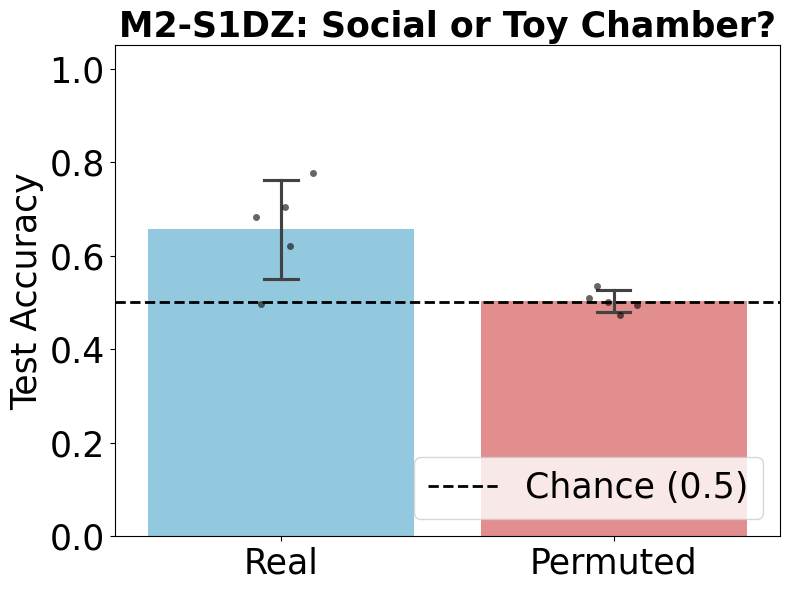

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.utils import resample
behavior_df = pd.read_csv(f"../../data/Motor_S1DZ_neurons/motor_x_y_from_crude_method_gaussianSigma25.csv")
neural_df = pd.read_csv("../../data/Motor_S1DZ_neurons/motor_trial1_deconvolved.csv")


# Extract base arrays
raw_neural_data = neural_df.to_numpy(dtype=float)
n_time_steps = raw_neural_data.shape[0]
x_coords = behavior_df["x"].to_numpy()
y_coords = behavior_df["y"].to_numpy()

# Compute Kinematics
dx = np.diff(x_coords, prepend=x_coords[0])
dy = np.diff(y_coords, prepend=y_coords[0])
velocity = np.sqrt(dx**2 + dy**2)
is_moving = np.where(velocity > 0, 1, 0)

# Zone Labeling
is_in_social_area = np.full(n_time_steps, -1)
is_in_social_area[x_coords < 220] = 0
is_in_social_area[x_coords > 450] = 1

# Create Master DataFrame for filtering
df = pd.DataFrame({
    'original_idx': np.arange(n_time_steps),
    'is_in_social_area': is_in_social_area,
    'is_moving': is_moving,
    'y_coords': y_coords
})

# Filtering: Remove transitions, keep only stationary, filter by Y-coord
df_filtered = df[(df['is_in_social_area'] != -1) & 
                 (df['is_moving'] == 0) & 
                 (df['y_coords'] > 260)].copy()

# Create strata for balancing (Social Zone + Movement state)
df_filtered['strata'] = df_filtered['is_in_social_area'].astype(str) #+ "_" + df_filtered['is_moving'].astype(str)
strata_filtered = df_filtered['strata'].values

# Storage for plotting at the end
all_accuracies = []
all_conditions = []

# ==========================================
# 2. Iterative Pipeline (Permutation vs Real)
# ==========================================
for permutation in [False, True]:
    print(f"\n{'='*65}\nRUNNING PIPELINE: PERMUTATION = {permutation}\n{'='*65}")
    
    # Shuffle neural data if permutation run
    neural_data = np.random.permutation(raw_neural_data) if permutation else raw_neural_data.copy()
    X_filtered_all = neural_data[df_filtered['original_idx'].values]

    # CV Configuration: Grouped by time chunks to prevent leakage
    chunk_size = 2500
    groups = np.repeat(np.arange(len(df_filtered) // chunk_size + 1), chunk_size)[:len(df_filtered)]

    n_splits = 5
    cv = StratifiedGroupKFold(n_splits=n_splits, shuffle=True, random_state=42)
    
    cv_scores = []
    train_sizes, test_sizes = [], []

    print(f"Starting {n_splits}-Fold CV (Train & Test Downsampled)...")

    for fold, (train_idx, test_idx) in enumerate(cv.split(X_filtered_all, strata_filtered, groups)):
        # Split dataframes
        df_train = df_filtered.iloc[train_idx].copy()
        df_test = df_filtered.iloc[test_idx].copy()
        
        # --- DOWNSAMPLE TRAINING DATA ---
        min_train_size = df_train['strata'].value_counts().min()
        train_groups = []
        for s_val, group in df_train.groupby('strata'):
            train_groups.append(resample(group, replace=False, n_samples=min_train_size, random_state=42))
        df_train_balanced = pd.concat(train_groups).sample(frac=1, random_state=42)
        
        # --- DOWNSAMPLE TEST DATA ---
        min_test_size = df_test['strata'].value_counts().min()
        test_groups = []
        for s_val, group in df_test.groupby('strata'):
            test_groups.append(resample(group, replace=False, n_samples=min_test_size, random_state=42))
        df_test_balanced = pd.concat(test_groups).sample(frac=1, random_state=42)
        
        # Logging
        print(f"\n[Fold {fold+1}] Balanced Strata Counts:")
        print(f"  Train: {df_train_balanced['strata'].value_counts().to_dict()}")
        print(f"  Test : {df_test_balanced['strata'].value_counts().to_dict()}")

        # Map back to neural data
        X_train = neural_data[df_train_balanced['original_idx'].values]
        y_train = df_train_balanced['is_in_social_area'].values
        X_test = neural_data[df_test_balanced['original_idx'].values]
        y_test = df_test_balanced['is_in_social_area'].values
        
        # Train and evaluate
        log_reg = LogisticRegression(max_iter=1000, n_jobs=-1)
        log_reg.fit(X_train, y_train)
        score = log_reg.score(X_test, y_test)
        cv_scores.append(score)
        
        print(f"  Accuracy: {score:.4f}")

    print(f"\nFinal Mean Accuracy: {np.mean(cv_scores):.4f} (+/- {np.std(cv_scores):.4f})")
    
    # Store results for final plot
    condition_label = "Permuted" if permutation else "Real"
    all_accuracies.extend(cv_scores)
    all_conditions.extend([condition_label] * len(cv_scores))

# ==========================================
# 3. Visualization
# ==========================================
# Create dataframe for Seaborn
results_df = pd.DataFrame({
    'Accuracy': all_accuracies,
    'Condition': all_conditions
})

plt.figure(figsize=(8, 6))

# Bar plot comparing Real vs Permuted
sns.barplot(data=results_df, x='Condition', y='Accuracy', palette=['skyblue', 'lightcoral'], capsize=.1, errorbar='sd')
# Overlay individual points for each fold
sns.stripplot(data=results_df, x='Condition', y='Accuracy', color='black', alpha=0.6, jitter=True)

plt.axhline(0.5, color='black', linestyle='--', linewidth=2, label='Chance (0.5)')
plt.ylim(0, 1.05)
plt.title(f'M2-S1DZ: Social or Toy Chamber?', fontsize=25, fontweight='bold')

# --- Updated sizes for labels, ticks, and legend ---
plt.ylabel('Test Accuracy', fontsize=25)
plt.xlabel('')
plt.xticks(fontsize=25)
plt.yticks(fontsize=25)
plt.legend(loc='lower right', fontsize=25)

plt.tight_layout()